In [50]:
from DCGAN.unet import UNet
import torch
from CityScapes import CityscapesDataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scale_for_display = lambda x: torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


In [51]:
channels=[512, 256, 128, 64, 32, 16, 8]
n_components=  2
img_channels = 3

In [52]:

train_dataset = CityscapesDataset()
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


segmentation_model =UNet(channels = channels,
                         out_channels=n_components,
                         cut_connections=4).to(device)
reconstruction_model = UNet(channels = channels,
                            out_channels=img_channels*n_components,
                            cut_connections=4).to(device)

segmentation_optimizer = torch.optim.Adam(segmentation_model.parameters(), lr=1e-4)
reconstruction_optimizer = torch.optim.Adam(reconstruction_model.parameters(), lr=1e-4)


reconstructions_loss_fn = torch.nn.MSELoss()


In [53]:
import torch
import torch.nn.functional as F

def combine_reconstructions(
    reconstruction_logits: torch.Tensor,  # (b, n, rgb, h, w)
    segmentation_logits: torch.Tensor,    # (b, n, h, w)
) -> torch.Tensor:
    """
    Differentiably combines n reconstructions using n segmentation masks.

    Args:
        reconstructions: (B, N, C, H, W) — per-slot/component reconstructed images
        segmentations:   (B, N, H, W)    — per-slot/component logits or soft masks

    Returns:
        combined: (B, C, H, W) — weighted sum over the N dimension
    """
    # Normalize segmentation weights over the N slots → (B, N, H, W)
    b,_,h,w =reconstruction_logits.shape
    reconstruction_logits=  reconstruction_logits.view(b,-1,3,h,w)
    segmentation = F.softmax(segmentation_logits, dim=1)

    # Expand weights to match reconstruction channels → (B, N, 1, H, W)
    segmentation = segmentation.unsqueeze(2)

    # Weighted sum over N → (B, C, H, W)
    combined = (reconstruction_logits * segmentation).sum(dim=1)
    combined = torch.tanh(combined)                     # bound to [-1, 1]
    return combined, segmentation

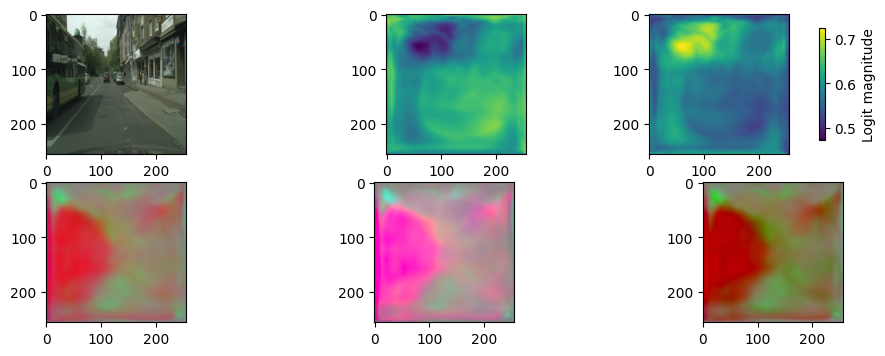

In [54]:


real,_ = next(iter(train_loader))
real = real.to(device)

with torch.no_grad():
    segmentation_logits =segmentation_model(real)
    reconstruction_logits = reconstruction_model(real)
    generated, segmentation = combine_reconstructions(reconstruction_logits, segmentation_logits)



n_components = segmentation_logits.shape[1]

scaled_real = scale_for_display(real)
scaled_generated = scale_for_display(generated)
fig,ax = plt.subplots(2,n_components+1,figsize=(12,4))
ax[0,0].imshow(scaled_real[0].permute(1,2,0).cpu().numpy())
ax[1,0].imshow(scaled_generated[0].permute(1,2,0).cpu().numpy())


sclaed_reconstruction_logits = scale_for_display(reconstruction_logits)
logits_np = segmentation.cpu().numpy()[0]  # shape: (num_classes, H, W)
vmin, vmax = logits_np.min(), logits_np.max()
for i in range(n_components):
    im = ax[0,i+1].imshow(segmentation.cpu().numpy()[0,i,0])
    rec= sclaed_reconstruction_logits[0,i*img_channels:(i+1)*img_channels].permute(1,2,0).cpu().numpy()
    ax[1,i+1].imshow(rec)

fig.colorbar(im, ax=ax[0, 1:], shrink=0.8, label="Logit magnitude")


In [55]:
from DCGAN.loss_functions import GradientPenaltyLoss, WeightedMSELoss, DriftLoss, EntropyLoss
entroply_loss_fn = EntropyLoss(10)

In [66]:
epochs = 20

for epoch in range(0, epochs):
    loop = tqdm(train_loader)

    loop.set_description(f"Epoch {epoch}/{epochs}")

    for real,_ in loop:
        reconstruction_optimizer.zero_grad()
        segmentation_optimizer.zero_grad()
        real = real.to(device)
        segmentation_logits =segmentation_model(real)
        reconstruction_logits = reconstruction_model(real)
        generated,_ = combine_reconstructions(reconstruction_logits, segmentation_logits)

        reconstruction_loss = reconstructions_loss_fn(generated, real)

        entropy_loss =entroply_loss_fn(segmentation_logits)
        loss =reconstruction_loss + entropy_loss
        loss.backward()
        segmentation_optimizer.step()
        reconstruction_optimizer.step()
        loop.set_postfix(loss=loss.item())

Epoch 3/20:  81%|████████  | 1014/1250 [03:10<00:44,  5.32it/s, loss=0.0179]


KeyboardInterrupt: 

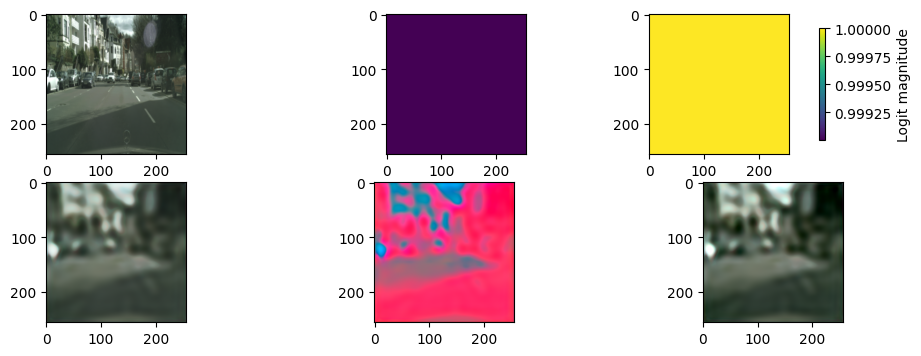

In [68]:


real,_ = next(iter(train_loader))
real = real.to(device)

with torch.no_grad():
    segmentation_logits =segmentation_model(real)
    reconstruction_logits = reconstruction_model(real)
    generated, segmentation = combine_reconstructions(reconstruction_logits, segmentation_logits)



n_components = segmentation_logits.shape[1]

scaled_real = scale_for_display(real)
scaled_generated = scale_for_display(generated)
fig,ax = plt.subplots(2,n_components+1,figsize=(12,4))
ax[0,0].imshow(scaled_real[0].permute(1,2,0).cpu().numpy())
ax[1,0].imshow(scaled_generated[0].permute(1,2,0).cpu().numpy())


sclaed_reconstruction_logits = scale_for_display(reconstruction_logits)
logits_np = segmentation.cpu().numpy()[0]  # shape: (num_classes, H, W)
vmin, vmax = logits_np.min(), logits_np.max()
for i in range(n_components):
    im = ax[0,i+1].imshow(segmentation.cpu().numpy()[0,i,0])
    rec= sclaed_reconstruction_logits[0,i*img_channels:(i+1)*img_channels].permute(1,2,0).cpu().numpy()
    ax[1,i+1].imshow(rec)

fig.colorbar(im, ax=ax[0, 1:], shrink=0.8, label="Logit magnitude")


In [ ]:
from DCGAN.modules.blocks import SpatialVectorizer
from 
import torch

sp_vec = SpatialVectorizer(in_channels=3, 
                           out_channels=3, 
                           number_of_components=4, 
                           degrees_of_freedom=8)

x = torch.randn(1, 3, 128, 128)

out = sp_vec(x)
out.shape

torch.Size([1, 4, 3, 128, 128])